# 8.2 商品期货动量策略（CTA）

## 为什么商品期货适合做动量策略？

商品期货动量是全球最大规模的另类策略之一——千亿级别的 CTA 基金。
**为什么商品期货比股票更适合趋势跟踪？**

1. **基本面驱动的趋势**：供需失衡往往持续数月甚至数年
   - 矿山建设周期 3-5 年（铜、铁矿石）
   - 作物生长周期不可逆（农产品）
   - 政策引导的能源转型（原油 → 电力）

2. **更低的反转倾向**：商品受实物约束，不像股票可以「纯情绪驱动」

3. **与股票相关性低**：CTA 策略的「危机 Alpha」——
   2008 年金融危机时，多数 CTA 基金盈利，而股票暴跌 40%

## 学习目标
- 理解时间序列动量（TSMOM）的信号构建逻辑
- 理解为什么要用波动率调整仓位（等波动率加权）
- 分析 CTA 策略与股票的相关性（危机期对冲价值）
- 截面动量 vs 时间序列动量的差异


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('OK')


OK


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 第一部分：时间序列动量（TSMOM）——为什么「顺势」有效？

### 动量的经济学机理

**为什么过去 12 个月上涨的商品，未来 1 个月往往还会继续涨？**

1. **基本面延迟传递**：铜价上涨 → 矿山投资增加 → 新矿建设 → 3 年后供给增加 → 价格回落  
   在这 3 年里，铜价可以持续上涨

2. **趋势追随机构规模效应**：CTA 资金本身的进场会推动价格进一步上涨（自我实现）

3. **信息逐步扩散**：基本面变化先被大宗商品现货交易商发现，慢慢扩散到金融市场

### TSMOM 信号构建

$$\text{Signal}_t(i) = \text{sign}\left(\sum_{k=1}^{K} r_{t-k}(i)\right)$$

- 过去 K 月收益为正 → 做多 (+1)
- 过去 K 月收益为负 → 做空 (-1)

### 为什么要波动率调整仓位？

如果不同品种的波动率相差 10 倍（原油 40% vs 黄金 12%），
等合约数目持有的话，风险完全由高波动品种决定。
**等波动率加权**使每个品种对组合风险的贡献相等。


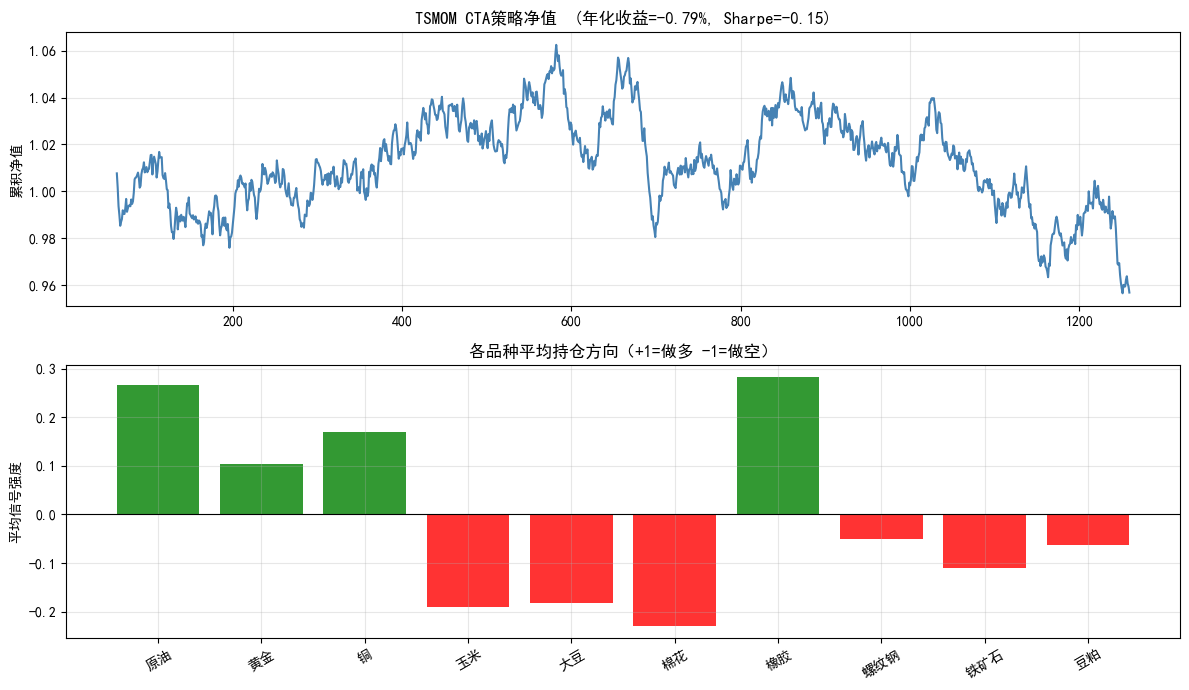

In [3]:
np.random.seed(42)
n_assets = 10
n_days   = 252 * 5
names    = ['原油','黄金','铜','玉米','大豆','棉花','橡胶','螺纹钢','铁矿石','豆粕']

# 生成带趋势特征的收益序列
returns = pd.DataFrame()
for i, name in enumerate(names):
    trend = 0.0003 * np.sin(np.linspace(0, 6*np.pi, n_days) + i)
    noise = np.random.normal(0, 0.015, n_days)
    returns[name] = trend + noise

lookback = 63   # 3 个月动量窗口
vol_target = 0.01  # 每日目标波动率

# 计算信号 & 波动率调整权重
signals  = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
for col in returns.columns:
    roll_ret = returns[col].rolling(lookback).sum()
    signals[col] = np.sign(roll_ret)

roll_vol = returns.rolling(21).std()
weights  = (vol_target / (roll_vol + 1e-8)).clip(upper=5)
strat_ret = (signals.shift(1) * weights.shift(1) * returns).mean(axis=1)

cum_strat = (1 + strat_ret).cumprod()
ann_ret   = strat_ret.mean() * 252
ann_vol   = strat_ret.std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
cum_strat.plot(ax=axes[0], color='steelblue', lw=1.5)
axes[0].set_title(f'TSMOM CTA策略净值  (年化收益={ann_ret:.2%}, Sharpe={ann_ret/ann_vol:.2f})')
axes[0].set_ylabel('累积净值'); axes[0].grid(alpha=0.3)

# 展示各品种平均持仓方向
avg_signal = signals.mean()
colors = ['green' if x > 0 else 'red' for x in avg_signal]
axes[1].bar(names, avg_signal.values, color=colors, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('各品种平均持仓方向（+1=做多 -1=做空）')
axes[1].set_ylabel('平均信号强度')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 第二部分：CTA 的「危机 Alpha」——与股票的相关性分析

**危机 Alpha** 是指：在股票市场大幅下跌时，CTA 策略往往获得正收益。
这是 CTA 最重要的价值——它提供真正意义上的多元化。

**为什么 CTA 在危机中表现好？**

- 危机时大宗商品（尤其是黄金、国债期货）往往出现明显趋势
- CTA 能做空股指期货（大跌时做空获利）
- 但注意：危机**初期**的急剧超跌往往摧毁短期动量信号


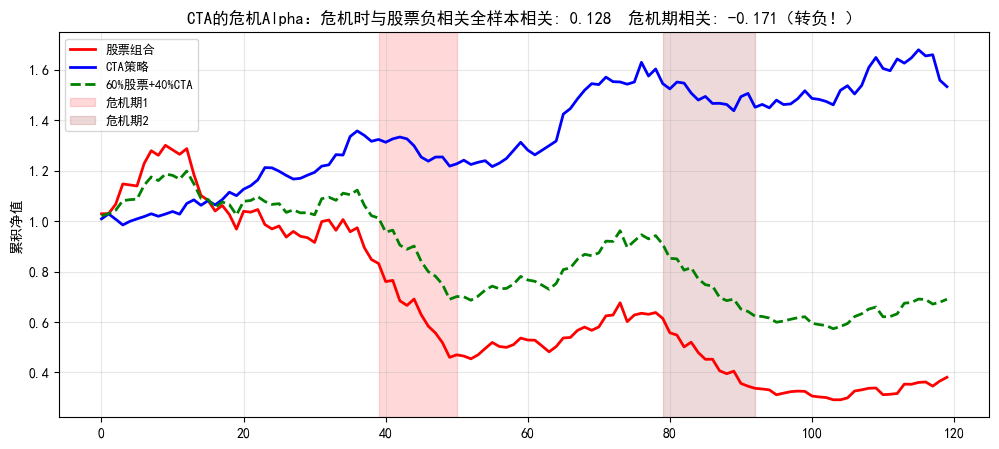

In [6]:
np.random.seed(42)
months = 120
# 模拟股票市场（含 2 次危机）
stock_ret = np.random.normal(0.007, 0.045, months)
stock_ret[39:50] = np.random.normal(-0.05, 0.04, 11)  # 第一次危机
stock_ret[79:92] = np.random.normal(-0.04, 0.05, 13)  # 第二次危机
# CTA 与股票负相关（危机时 CTA 表现更好）
phase = np.where((np.arange(months) >= 39) & (np.arange(months) < 50), -1,
        np.where((np.arange(months) >= 79) & (np.arange(months) < 92), -1, 1))
cta_ret = 0.004 * phase + np.random.normal(0, 0.02, months)

cum_stock = (1 + pd.Series(stock_ret)).cumprod()
cum_cta   = (1 + pd.Series(cta_ret)).cumprod()
cum_60_40 = (1 + pd.Series(0.6*stock_ret + 0.4*cta_ret)).cumprod()

corr_full   = np.corrcoef(stock_ret, cta_ret)[0,1]
crisis_mask = phase < 0
corr_crisis = np.corrcoef(stock_ret[crisis_mask], cta_ret[crisis_mask])[0,1]

plt.figure(figsize=(12, 5))
plt.plot(cum_stock, 'r', lw=2, label='股票组合')
plt.plot(cum_cta,   'b', lw=2, label='CTA策略')
plt.plot(cum_60_40, 'g', lw=2, linestyle='--', label='60%股票+40%CTA')
plt.axvspan(39, 50, alpha=0.15, color='red', label='危机期1')
plt.axvspan(79, 92, alpha=0.15, color='darkred', label='危机期2')

plt.title(f'CTA的危机Alpha：危机时与股票负相关'
          f'全样本相关: {corr_full:.3f}  危机期相关: {corr_crisis:.3f}（转负！）')
plt.ylabel('累积净值'); plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.show()


## 🎯 练习

1. 将TSMOM的回望窗口从3个月扩展到1个月、6个月、12个月，对比哪个窗口Sharpe最高。
2. 对比CTA策略在2008年金融危机（模拟）期间与股票60/40组合的最大回撤，验证危机Alpha。
3. 研究AQR的TSMOM论文（Moskowitz等2012），复现其在58个期货品种上的历史Sharpe Ratio。

---
**下一节** → `03_term_structure_strategy.ipynb`